# Etapa 3 — Análise das Features Extraídas

**Pré-requisito:** o notebook `02_limpeza_preparacao.ipynb` deve ter sido executado.
Ele gerou `data/processed/features_window_class.parquet` com as 88 features e os 17 estados operacionais.

Este notebook explora o que foi gerado:
- Como é a distribuição dos 17 estados operacionais (Normal + 9 Ativos + 7 Transientes)?
- Quais features têm mais variância (mais informação)?
- As classes estão bem separadas no espaço de features?
- Tem alguma feature com NaN que precisa ser tratada antes da modelagem?

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import WINDOW_CLASSES, FEATURES_WINDOW_PATH, VALIDATION_MODE

print('Bibliotecas carregadas!')
mode_label = 'VALIDACAO' if VALIDATION_MODE else 'COMPLETO'
print(f'Modo atual: {mode_label}')
print(f'Dataset: features_window_class.parquet (17 estados operacionais)')

## 3.1 Carregar features (geradas pelo notebook 02)

In [ ]:
df = pd.read_parquet(FEATURES_WINDOW_PATH)

META_COLS = ['instance_id', 'fault_class', 'window_label', 'source_type', 'window_start']
feature_cols = [c for c in df.columns if c not in META_COLS]

print(f'Shape: {df.shape}')
print(f'Janelas totais   : {len(df):,}')
print(f'Features/janela  : {len(feature_cols)}')
print(f'Instâncias únicas: {df["instance_id"].nunique()}')
print(f'Classes          : {sorted(df["window_label"].unique())}')

# Amostra de features do sensor P-TPT (verificar que a normalização funcionou)
sample = df[df['window_label'] == 1].head(3)
display_cols = [c for c in feature_cols if 'P-TPT' in c]
print(f'\nAmostra de features P-TPT (classe 1 — BSW Ativo, após z-score por instância):')
print(sample[display_cols].round(3).to_string())

## 3.2 Distribuição dos 17 estados operacionais

Cada janela recebe o estado predominante naquele intervalo de 300 s:
- **0** — Normal
- **1–9** — Evento Ativo (falha instalada)
- **101–109** — Transiente (falha se aproximando)

> **Desbalanceamento:** A diferença entre a classe mais frequente e a mais rara pode chegar a
> 112:1. Por isso usamos `class_weight='balanced'` nos modelos — cada classe contribui
> igualmente para o gradiente de aprendizado, independentemente de sua frequência.

In [ ]:
window_counts = df['window_label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#2ecc71' if c == 0 else ('#e74c3c' if c < 100 else '#f39c12')
          for c in window_counts.index]
labels = [f'{k}\n{WINDOW_CLASSES.get(k, str(k))[:15]}' for k in window_counts.index]
ax.bar(labels, window_counts.values, color=colors)
ax.set_title('Janelas por Estado Operacional (17 classes)')
ax.set_ylabel('Janelas')
ax.tick_params(axis='x', rotation=30, labelsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Normal (0)'),
    Patch(facecolor='#e74c3c', label='Ativo (1–9)'),
    Patch(facecolor='#f39c12', label='Transiente (101–109)'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

print('\nJanelas por estado operacional:')
for cls, count in window_counts.items():
    pct = 100 * count / len(df)
    label = WINDOW_CLASSES.get(cls, str(cls))
    print(f'  {cls:>3} — {label:<30}: {count:>7,} ({pct:.1f}%)')

## 3.3 Qualidade: NaN nas features

Janelas muito curtas (no início ou fim de uma instância) podem gerar NaN em algumas features.
Na modelagem, usaremos um `SimpleImputer` para substituir esses valores pela mediana.

In [10]:
nan_counts = df[feature_cols].isna().sum()
cols_with_nan = nan_counts[nan_counts > 0].sort_values(ascending=False)

if cols_with_nan.empty:
    print('Nenhuma feature com NaN — dataset pronto para modelagem!')
else:
    print(f'{len(cols_with_nan)} features com NaN (serao tratadas com SimpleImputer na Etapa 4):')
    print(cols_with_nan.head(10).to_string())

44 features com NaN (serao tratadas com SimpleImputer na Etapa 4):
T-PDG_mean         18463
T-PDG_std          18463
T-PDG_min          18463
T-PDG_max          18463
T-PDG_skewness     18463
T-PDG_kurtosis     18463
T-PDG_median       18463
T-PDG_iqr          18463
T-PDG_diff1_std    18463
T-PDG_diff2_std    18463


## 3.4 Features com maior variância

Features com variância próxima de zero não trazem informação — o modelo as ignoraria.
Features com alta variância são candidatas a ser importantes para a classificação.

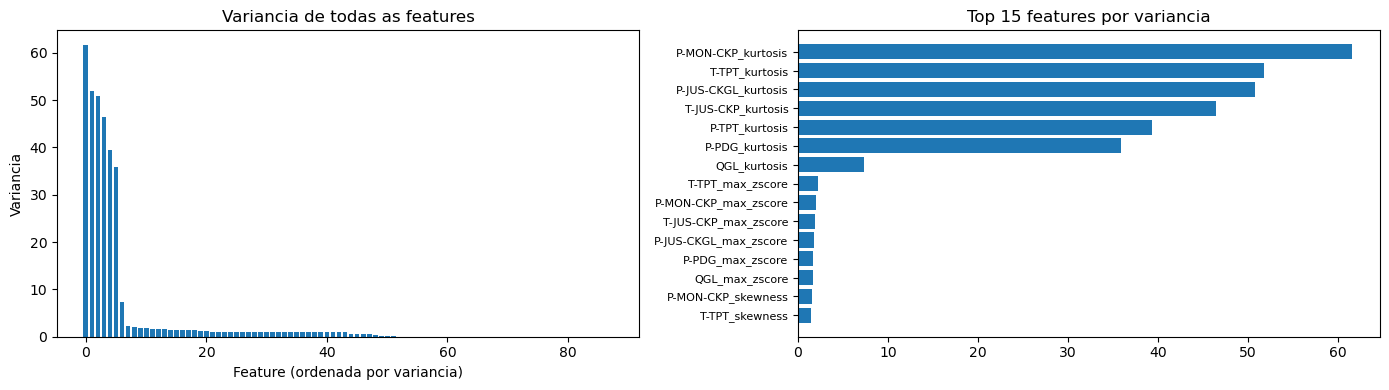

In [11]:
variances = df[feature_cols].var().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Todas as features
axes[0].bar(range(len(variances)), variances.values)
axes[0].set_title('Variancia de todas as features')
axes[0].set_xlabel('Feature (ordenada por variancia)')
axes[0].set_ylabel('Variancia')

# Top 15
top15 = variances.head(15)
axes[1].barh(range(len(top15)), top15.values)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15.index, fontsize=8)
axes[1].set_title('Top 15 features por variancia')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3.5 Separabilidade entre estados operacionais (boxplot)

Para uma feature ser útil, ela precisa ter distribuições **diferentes** entre os 17 estados.
Comparamos a feature de maior variância entre todos os estados.
Se as caixas estão em alturas diferentes, a feature ajuda a separar as classes.

In [ ]:
best_feature = variances.index[0]
sorted_classes = sorted(df['window_label'].unique())

fig, ax = plt.subplots(figsize=(16, 5))
data_by_class = [df[df['window_label'] == c][best_feature].dropna().values
                 for c in sorted_classes]
labels = [f'{k}\n{WINDOW_CLASSES.get(k, str(k))[:12]}' for k in sorted_classes]
colors = ['#2ecc71' if c == 0 else ('#e74c3c' if c < 100 else '#f39c12')
          for c in sorted_classes]

bp = ax.boxplot(data_by_class, labels=labels, patch_artist=True,
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title(f'Distribuição de "{best_feature}" por Estado Operacional (17 classes)')
ax.set_ylabel(best_feature)
ax.tick_params(axis='x', rotation=30, labelsize=7)
plt.tight_layout()
plt.show()

print(f'Feature analisada: {best_feature}')
print('Verde=Normal | Vermelho=Ativo | Laranja=Transiente')